
<a href="https://www.zero-grad.com/">
         <img alt="Zero Grad" src="https://i.postimg.cc/vBPDms4J/pythonml-2.png" >
      </a>

# Get the Data

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

In [74]:
import pandas as pd

housing = pd.read_csv("https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Take a Quick Look at the Data Structure

In [75]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [76]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [77]:
housing.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [78]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [79]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import plotly.express as px

px.scatter(housing, x="longitude", y="latitude", color="median_house_value",  title="Housing Prices", width=800, height=600)

        This image tells you that the housing prices are very much related to the location

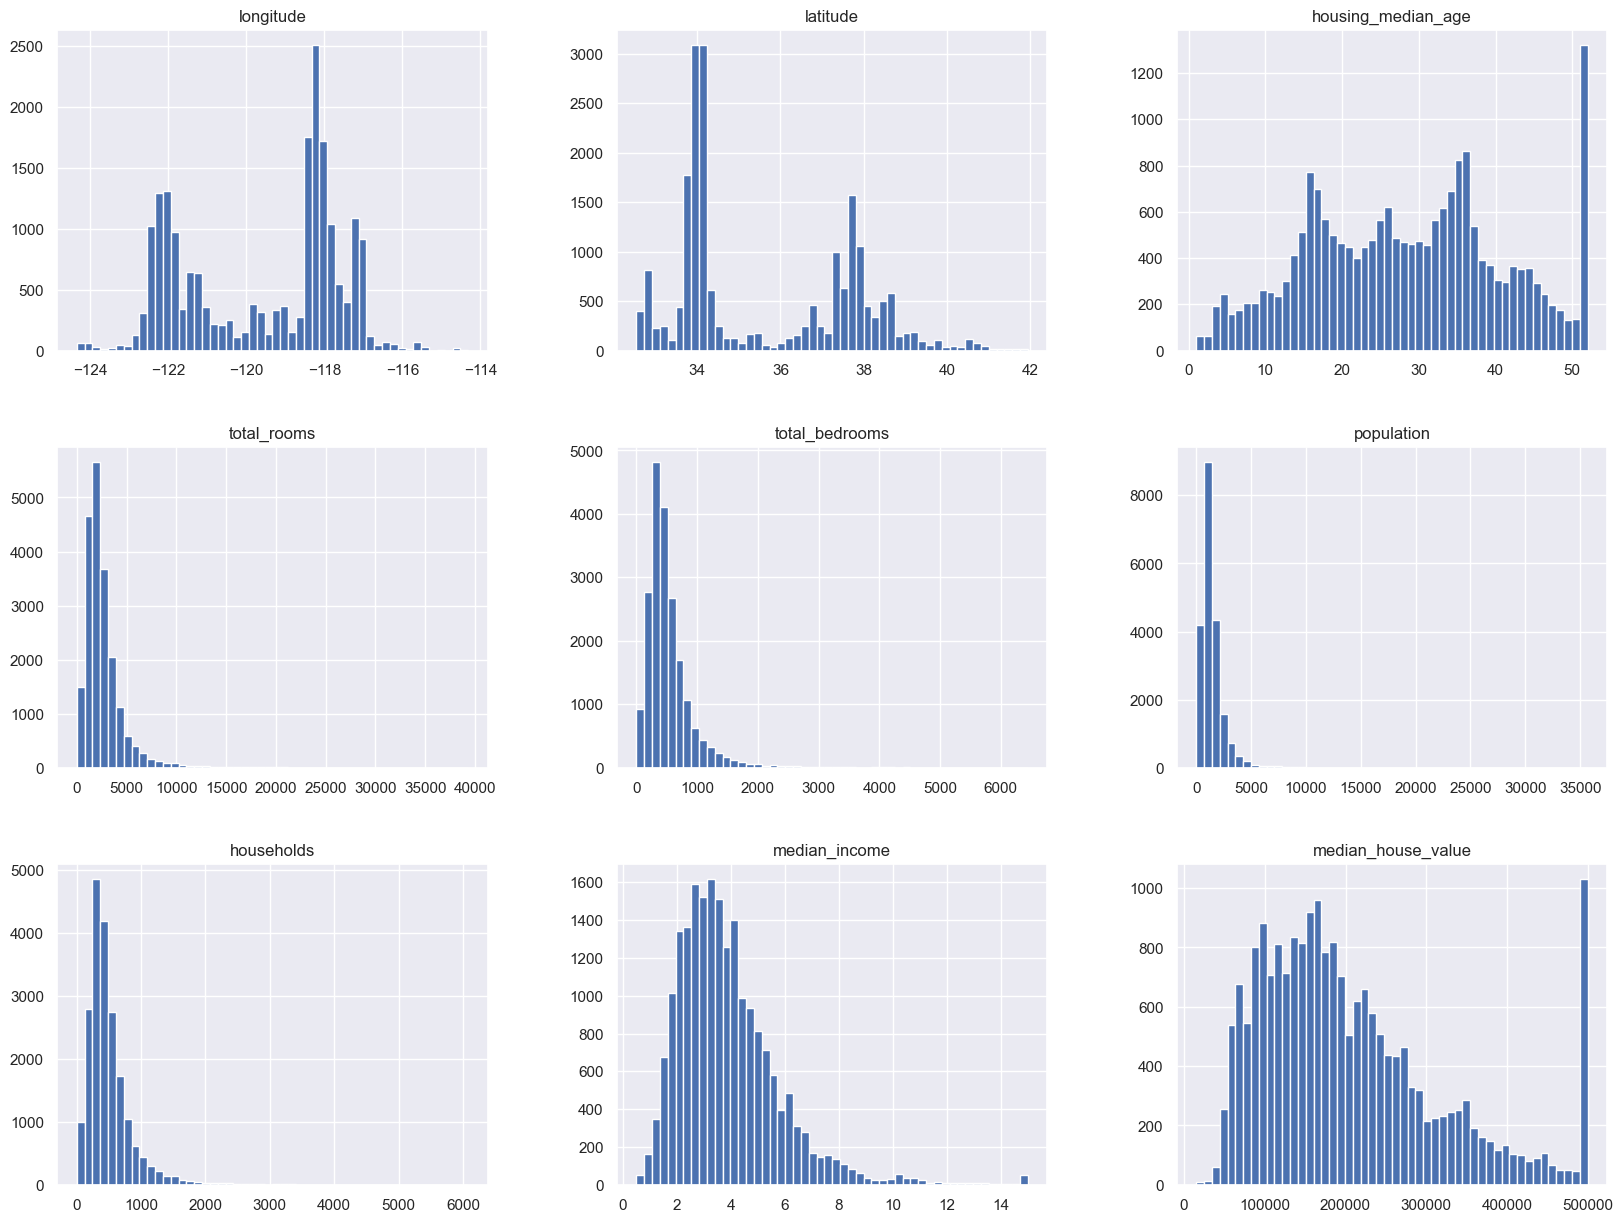

In [81]:
# Histograms
housing.hist(bins=50, figsize=(20,15));

There are a few things you might notice in these histograms:

1.  different scales: feature scaling.

4.  many histograms are tail-heavy: transforming to more bell-shaped distributions.


## Create a Test Set

In [82]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42) # random_state is used for reproducibility

In [83]:
train_set.shape, test_set.shape

((16512, 10), (4128, 10))

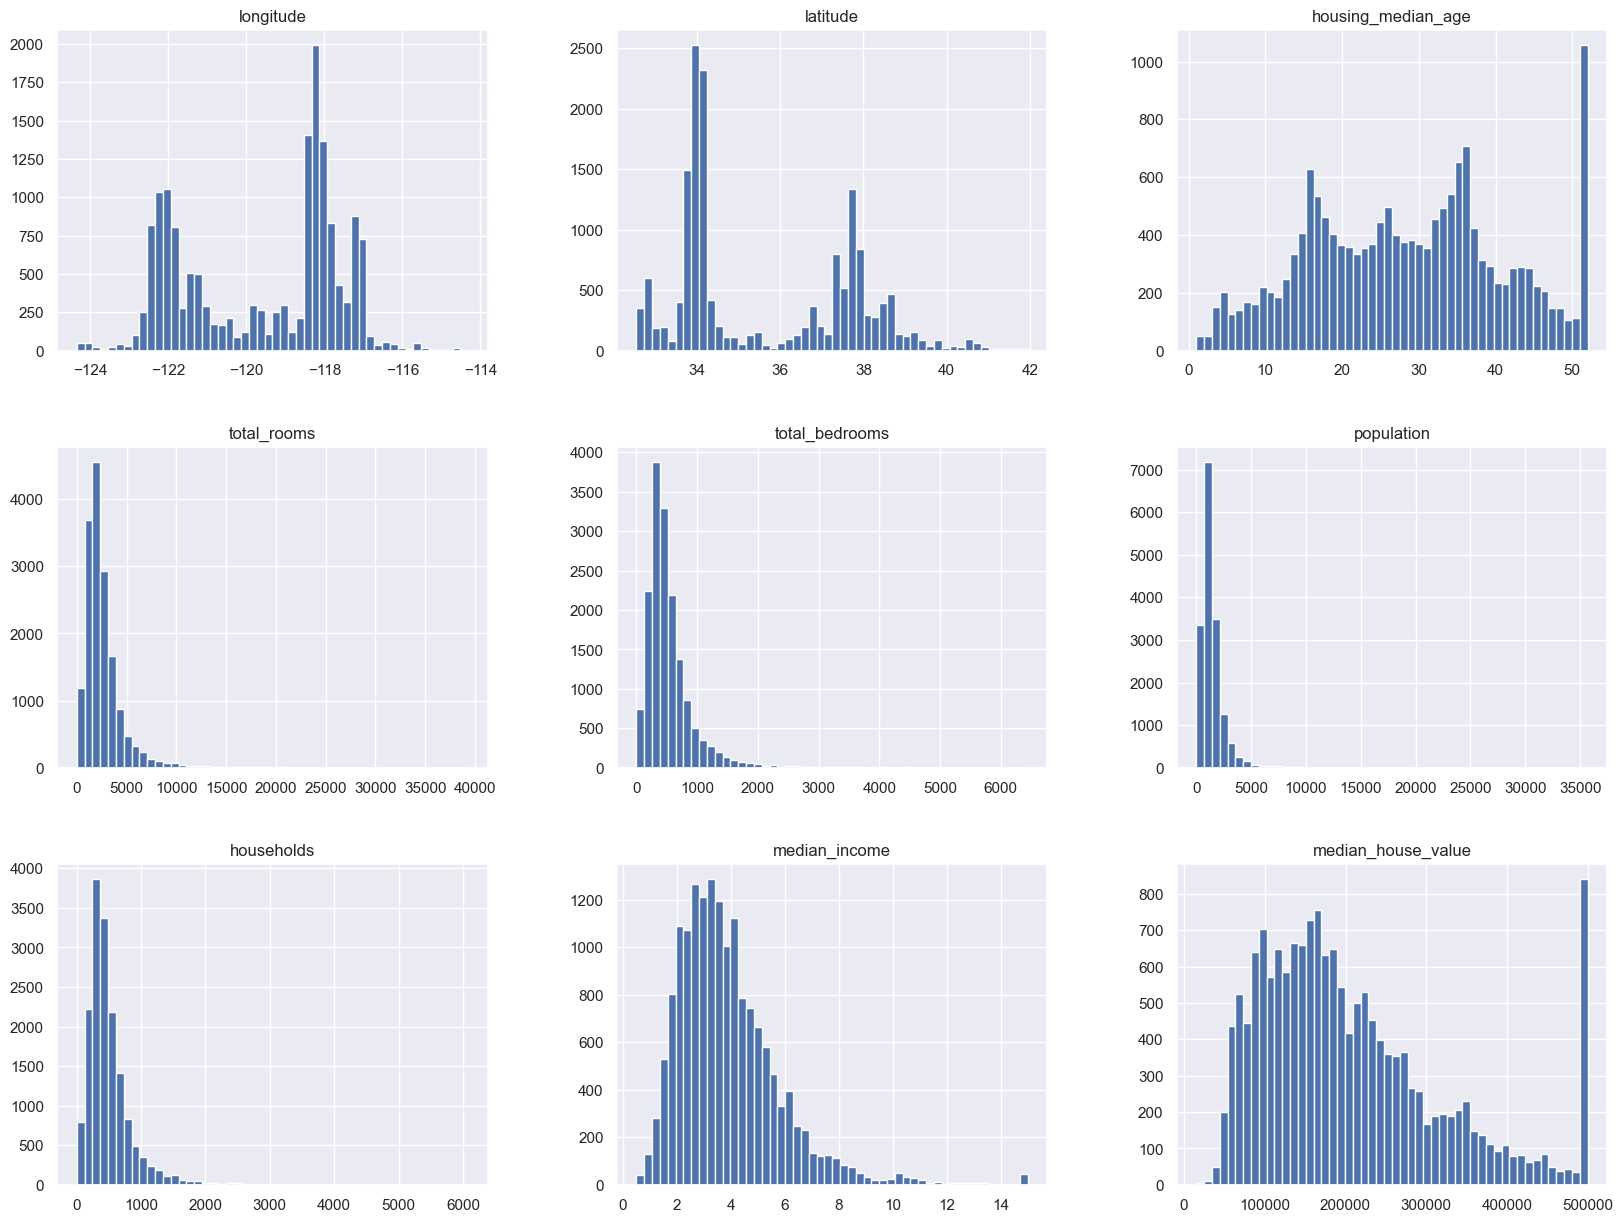

In [84]:
train_set.hist(bins=50, figsize=(20,15));

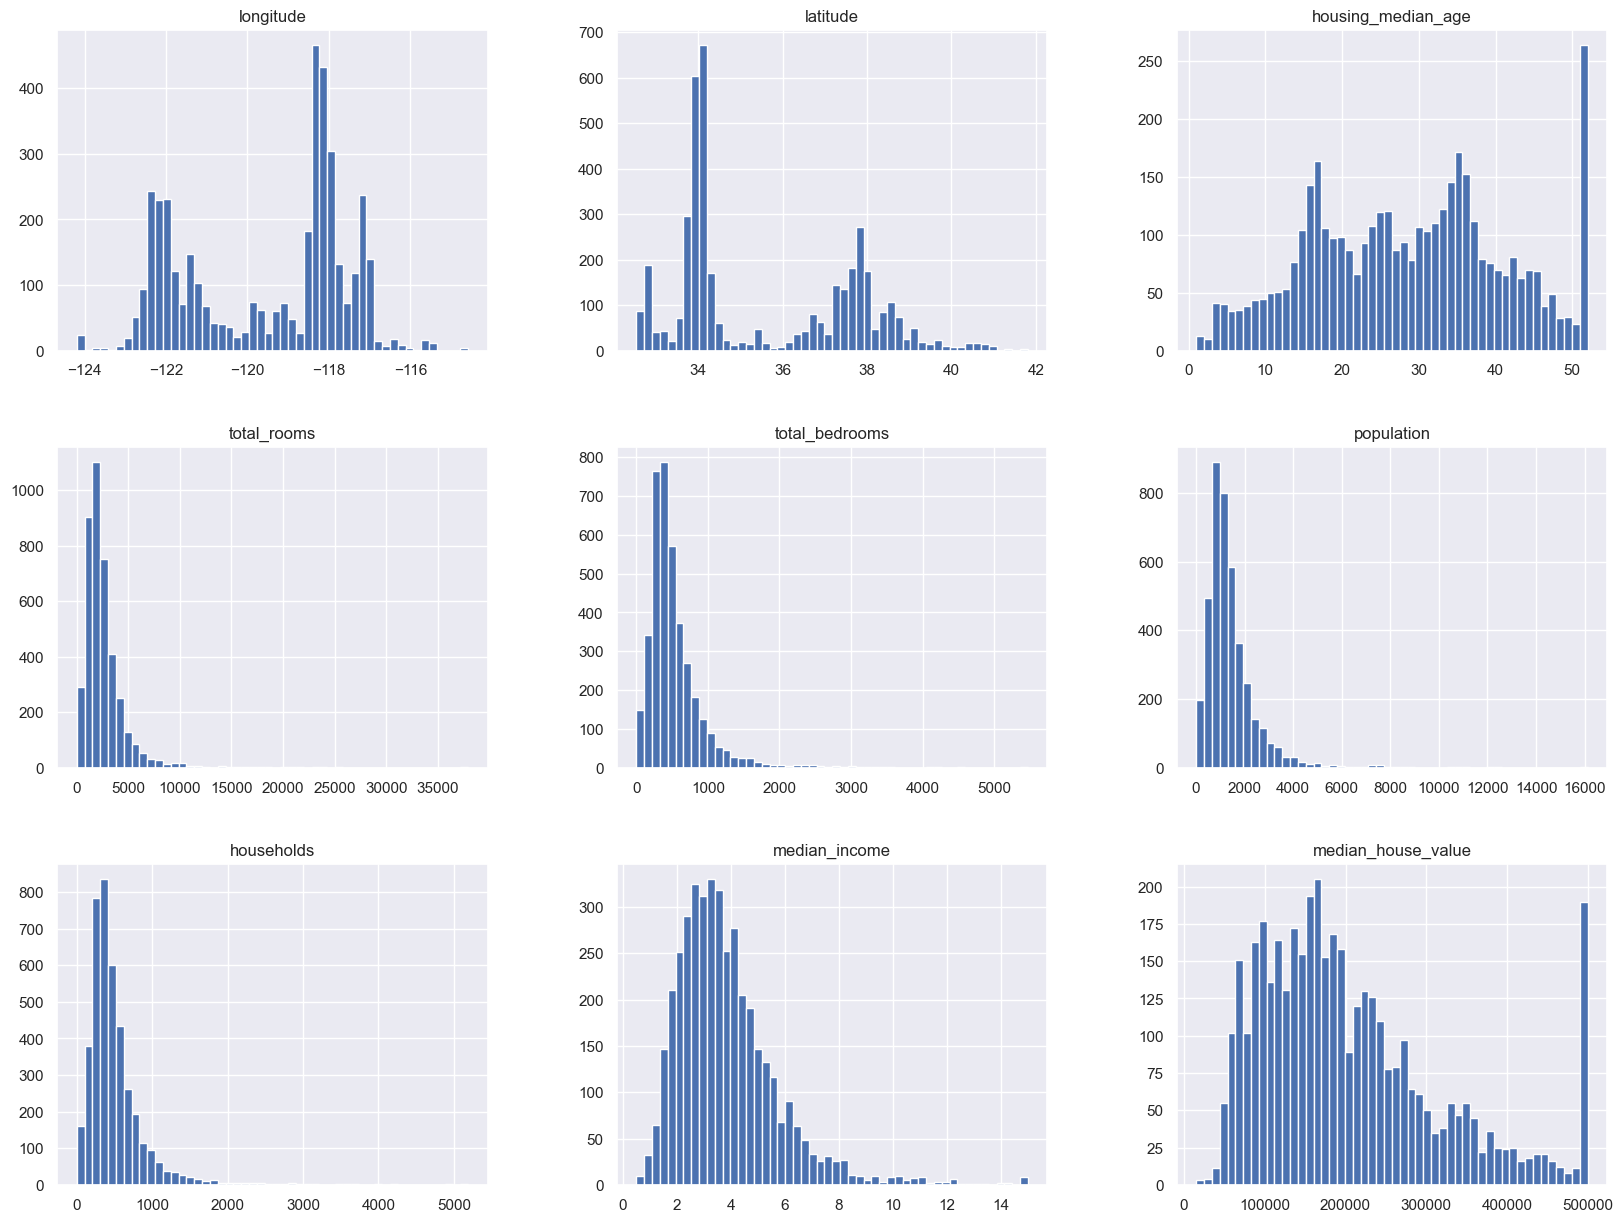

In [85]:
test_set.hist(bins=50, figsize=(20,15));

In [86]:
train_set.median_house_value.describe(), test_set.median_house_value.describe()

(count     16512.000000
 mean     207194.693738
 std      115622.626448
 min       14999.000000
 25%      119800.000000
 50%      179850.000000
 75%      265125.000000
 max      500001.000000
 Name: median_house_value, dtype: float64,
 count      4128.000000
 mean     205500.309593
 std      114486.964288
 min       14999.000000
 25%      119275.000000
 50%      178650.000000
 75%      263000.000000
 max      500001.000000
 Name: median_house_value, dtype: float64)

> **Note**: 

If our target is classes, we can use the parameter `stratify` in `train_test_split` to ensure that the test set is representative of the various classes in the training set.

# EDA

In [87]:
px.scatter(train_set, x="longitude", y="latitude", color="median_house_value",  title="Housing Prices", width=800, height=600)

In [88]:
train_set.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924485,-0.101818,0.038676,0.063064,0.094276,0.049306,-0.017040,-0.046349
latitude,-0.924485,1.000000,0.005296,-0.029224,-0.059998,-0.102499,-0.064061,-0.076571,-0.142983
housing_median_age,-0.101818,0.005296,1.000000,-0.360922,-0.320624,-0.292283,-0.302796,-0.121711,0.103706
total_rooms,0.038676,-0.029224,-0.360922,1.000000,0.930489,0.857936,0.920482,0.198268,0.133989
total_bedrooms,0.063064,-0.059998,-0.320624,0.930489,1.000000,0.878932,0.980255,-0.009141,0.047980
population,0.094276,-0.102499,-0.292283,0.857936,0.878932,1.000000,0.907452,0.004122,-0.026032
households,0.049306,-0.064061,-0.302796,0.920482,0.980255,0.907452,1.000000,0.012776,0.063714
median_income,-0.017040,-0.076571,-0.121711,0.198268,-0.009141,0.004122,0.012776,1.000000,0.690647
median_house_value,-0.046349,-0.142983,0.103706,0.133989,0.047980,-0.026032,0.063714,0.690647,1.000000


In [89]:
train_set.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.690647
total_rooms           0.133989
housing_median_age    0.103706
households            0.063714
total_bedrooms        0.047980
population           -0.026032
longitude            -0.046349
latitude             -0.142983
Name: median_house_value, dtype: float64

In [90]:
train_set.corr(numeric_only=True)["median_house_value"].apply(lambda x: abs(x)).sort_values(ascending=False)

median_house_value    1.000000
median_income         0.690647
latitude              0.142983
total_rooms           0.133989
housing_median_age    0.103706
households            0.063714
total_bedrooms        0.047980
longitude             0.046349
population            0.026032
Name: median_house_value, dtype: float64

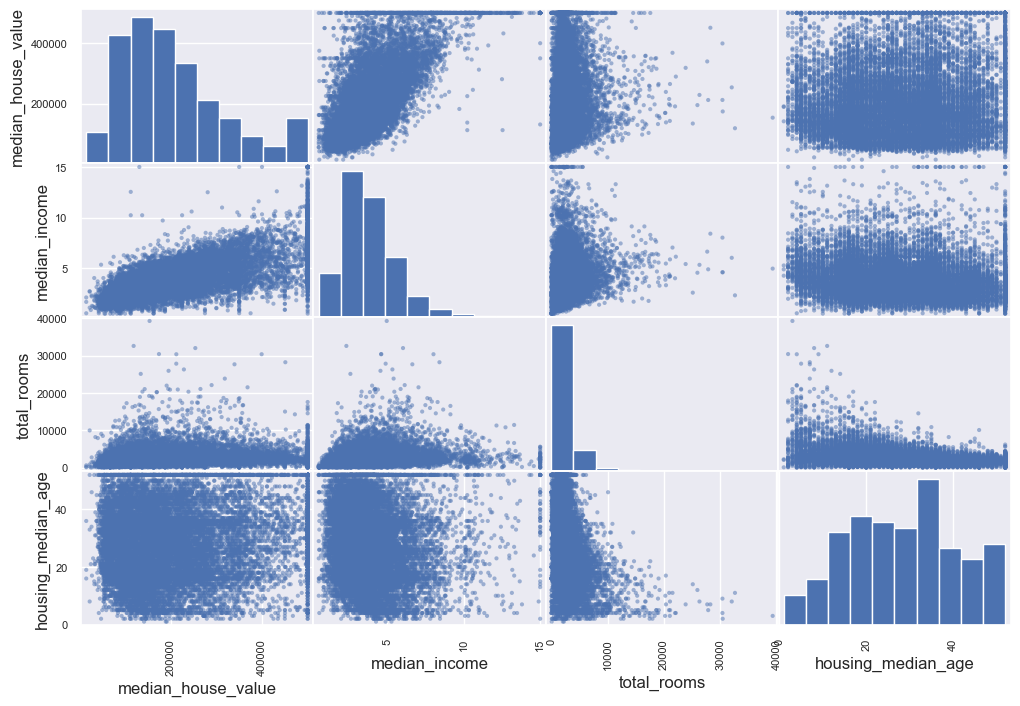

In [91]:
# scatter_matrix
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(train_set[attributes], figsize=(12, 8));

c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\ahmad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



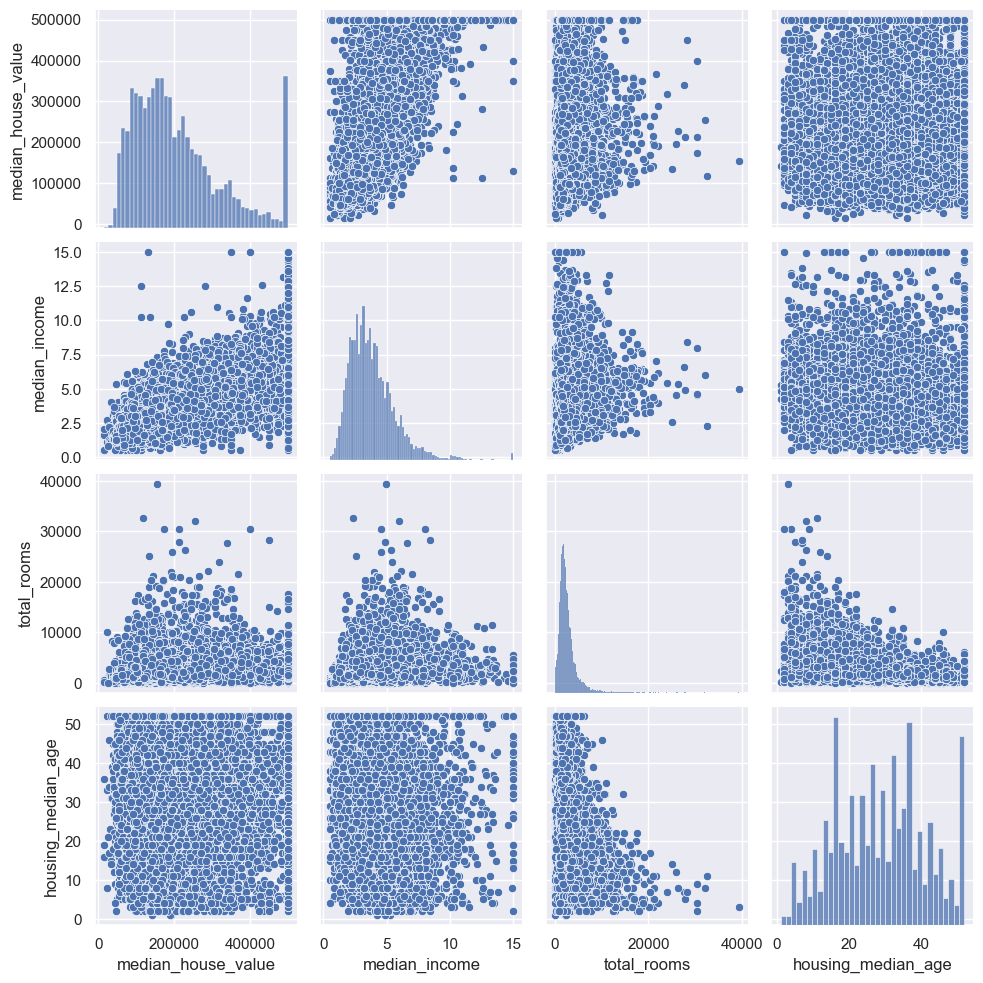

In [92]:
# pairplot
sns.pairplot(train_set[attributes]);

        The most promising attribute to predict the median house value is the median income

In [93]:
px.scatter(train_set, x="median_income", y="median_house_value", title="Housing Prices", width=800, height=600)

You have got an idea of a few ways you can explore the data and gain insights. 
* You identified a few data quirks that you may want to clean up before feeding the data to a Machine Learning algorithm
* You found interestingcorrelations between attributes, in particular with the target attribute. 
* You also noticed that some attributes have a tail-heavy distribution, so you may want to transform them (e.g., by computing their logarithm). 

Of course, your mileage will vary considerably with each project, but the general ideas are similar.

# Feature Engineering

In [94]:
# Rooms per household
train_set["rooms_per_household"] = train_set["total_rooms"]/train_set["households"]

# Bedrooms per room
train_set["bedrooms_per_room"] = train_set["total_bedrooms"]/train_set["total_rooms"]

# Population per household
train_set["population_per_household"] = train_set["population"]/train_set["households"]

In [95]:
train_set.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
longitude,1.000000,-0.924485,-0.101818,0.038676,0.063064,0.094276,0.049306,-0.017040,-0.046349,-0.029339,0.097280,-0.000598
latitude,-0.924485,1.000000,0.005296,-0.029224,-0.059998,-0.102499,-0.064061,-0.076571,-0.142983,0.110695,-0.118938,0.005837
housing_median_age,-0.101818,0.005296,1.000000,-0.360922,-0.320624,-0.292283,-0.302796,-0.121711,0.103706,-0.160892,0.135495,0.016245
total_rooms,0.038676,-0.029224,-0.360922,1.000000,0.930489,0.857936,0.920482,0.198268,0.133989,0.136090,-0.189316,-0.024991
total_bedrooms,0.063064,-0.059998,-0.320624,0.930489,1.000000,0.878932,0.980255,-0.009141,0.047980,-0.001659,0.084149,-0.028536
population,0.094276,-0.102499,-0.292283,0.857936,0.878932,1.000000,0.907452,0.004122,-0.026032,-0.073733,0.035134,0.072330
households,0.049306,-0.064061,-0.302796,0.920482,0.980255,0.907452,1.000000,0.012776,0.063714,-0.083062,0.064185,-0.027656
median_income,-0.017040,-0.076571,-0.121711,0.198268,-0.009141,0.004122,0.012776,1.000000,0.690647,0.336013,-0.616669,0.022061
median_house_value,-0.046349,-0.142983,0.103706,0.133989,0.047980,-0.026032,0.063714,0.690647,1.000000,0.158485,-0.257419,-0.022030
rooms_per_household,-0.029339,0.110695,-0.160892,0.136090,-0.001659,-0.073733,-0.083062,0.336013,0.158485,1.000000,-0.435169,-0.004922


In [96]:
# Correlation matrix
train_set.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.690647
rooms_per_household         0.158485
total_rooms                 0.133989
housing_median_age          0.103706
households                  0.063714
total_bedrooms              0.047980
population_per_household   -0.022030
population                 -0.026032
longitude                  -0.046349
latitude                   -0.142983
bedrooms_per_room          -0.257419
Name: median_house_value, dtype: float64

In [97]:
# Absolute correlation matrix
train_set.corr(numeric_only=True)["median_house_value"].apply(lambda x: abs(x)).sort_values(ascending=False)

median_house_value          1.000000
median_income               0.690647
bedrooms_per_room           0.257419
rooms_per_household         0.158485
latitude                    0.142983
total_rooms                 0.133989
housing_median_age          0.103706
households                  0.063714
total_bedrooms              0.047980
longitude                   0.046349
population                  0.026032
population_per_household    0.022030
Name: median_house_value, dtype: float64

* `bedrooms_per_room` is more informative than `total_bedrooms` or `total_rooms`.
* `rooms_per_household` is also more informative than `total_rooms` or `households`.

# Prepare the Data for Machine Learning Algorithms

In [98]:
# Split the data into features and labels

train_features = train_set.drop("median_house_value", axis=1)
train_labels = train_set["median_house_value"].copy()

# Data Cleaning

## Missing Values

In [99]:
test_set.total_bedrooms.isnull().sum()

207

In [100]:
train_set.total_bedrooms.isnull().sum()

0

In [101]:
housing.total_bedrooms.isnull().sum()

207

In [102]:
housing[housing.total_bedrooms.isnull()].index

Index([  290,   341,   538,   563,   696,   738,  1097,  1350,  1456,  1493,
       ...
       19932, 19959, 20046, 20069, 20125, 20267, 20268, 20372, 20460, 20484],
      dtype='int64', length=207)

> **Handling missing values:**
1. **Drop Instances**
 ``` python
 housing.dropna(subset=["total_bedrooms"])
 ```
                
2. **Drop Attribute**
``` python
housing.drop("total_bedrooms", axis=1)
```
3. **Impute Values**
``` python
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)
```


In [103]:
# Impute missing values with median using SimpleImputer

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

# Remove the text attribute because median can only be calculated on numerical attributes
housing_num = train_features.drop("ocean_proximity", axis=1)

# Fit the imputer instance to the training data using the fit() method
imputer.fit(housing_num) 

# The imputer has simply computed the median of each attribute and stored the result in its statistics_ instance variable
imputer.statistics_

array([-118.51      ,   34.26      ,   29.        , 2129.        ,
        437.        , 1167.        ,  410.        ,    3.5458    ,
          5.23587365,    0.20280765,    2.81723971])

In [104]:
# format the output to be more readable
import numpy as np
np.set_printoptions(suppress=True)
imputer.statistics_

array([-118.51      ,   34.26      ,   29.        , 2129.        ,
        437.        , 1167.        ,  410.        ,    3.5458    ,
          5.23587365,    0.20280765,    2.81723971])

In [105]:
housing_num.median().values

array([-118.51      ,   34.26      ,   29.        , 2129.        ,
        437.        , 1167.        ,  410.        ,    3.5458    ,
          5.23587365,    0.20280765,    2.81723971])

> Imputer fitting:
* Just calculate the median of each attribute and store the result in its `statistics_` instance variable.
* Fitting done only on the training set, not on the full dataset (including the test set).
> Imputer transformation:
* Replace missing values by the learned medians.
* Transformation done on both the training set and the test set.

In [106]:
X = imputer.transform(housing_num)
X # returns a numpy array

array([[-117.03      ,   32.71      ,   33.        , ...,    5.0176565 ,
           0.20057582,    3.6918138 ],
       [-118.16      ,   33.77      ,   49.        , ...,    4.47354497,
           0.23270254,    1.73809524],
       [-120.48      ,   34.66      ,    4.        , ...,    5.64583333,
           0.17448603,    2.72321429],
       ...,
       [-118.38      ,   34.03      ,   36.        , ...,    3.98671727,
           0.27082342,    3.33206831],
       [-121.96      ,   37.58      ,   15.        , ...,    6.39534884,
           0.16699301,    3.17889088],
       [-122.42      ,   37.77      ,   52.        , ...,    3.40257649,
           0.31116895,    2.10869565]])

In [107]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,5.017657,0.200576,3.691814
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,4.473545,0.232703,1.738095
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,5.645833,0.174486,2.723214
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,4.002817,0.258269,3.994366
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,6.268421,0.180940,2.300000


# Handling Text and Categorical Attributes

In [108]:
housing_cat = train_features[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
14196,NEAR OCEAN
8267,NEAR OCEAN
17445,NEAR OCEAN
14265,NEAR OCEAN
2271,INLAND
17848,<1H OCEAN
6252,<1H OCEAN
9389,NEAR BAY
6113,<1H OCEAN
6061,<1H OCEAN


In [109]:
housing_cat["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7341
INLAND        5227
NEAR OCEAN    2086
NEAR BAY      1854
ISLAND           4
Name: count, dtype: int64

> If it was ordinal, we could just replace the categories with numbers (e.g., “bad” = 0, “average” = 1, “good” = 2, “excellent” = 3),
 and it is available in Scikit-Learn as `OrdinalEncoder`.

> If it is nominal, as in our case, we need to use a one-hot encoding, which is available using a `OneHotEncoder` class in Scikit-Learn.

In [110]:
# OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot # returns a sparse matrix

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

> Note:
 the output is a SciPy sparse matrix, instead of a NumPy array. 
        
        This is very useful when you have categorical attributes with thousands of categories. After onehot encoding, we get a matrix with thousands of columns, and the matrix is full of 0s except for a single 1 per row. Using up tons of memory mostly to store zeros would be very wasteful, so instead a sparse matrix only stores the location of the nonzero elements. You can use it mostly like a normal 2D array, but if you really want to convert it to a (dense) NumPy array, just call the toarray() method:

In [111]:
# Convert sparse matrix to a dense matrix
housing_cat_1hot.toarray()

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [112]:
# Make 'sparse=False' to get a dense matrix
cat_encoder = OneHotEncoder(sparse=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [113]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

> Note:
       
        One hot encoding is not a good idea for categorical attributes with large number of categories. For example, if a categorical attribute has a 1000 categories, after one-hot encoding we will have 1000 input features. This will slow down training and degrade performance. We must use other encoding techniques in this case.

# Feature Scaling

In [114]:
housing_num.describe().loc[["min", "max"]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
min,-124.35,32.55,1.0,2.0,1.0,3.0,1.0,0.4999,0.888889,0.1,0.692308
max,-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,141.909091,1.0,1243.333333


        With few exceptions, Machine Learning algorithms don’t perform well when the input numerical attributes have very different scales.

 There are two common ways to get all attributes to have the same scale: min-max scaling and standardization. 


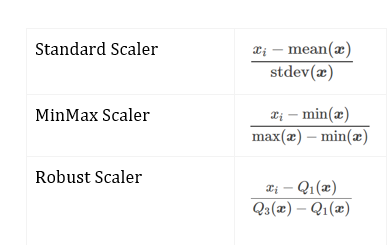

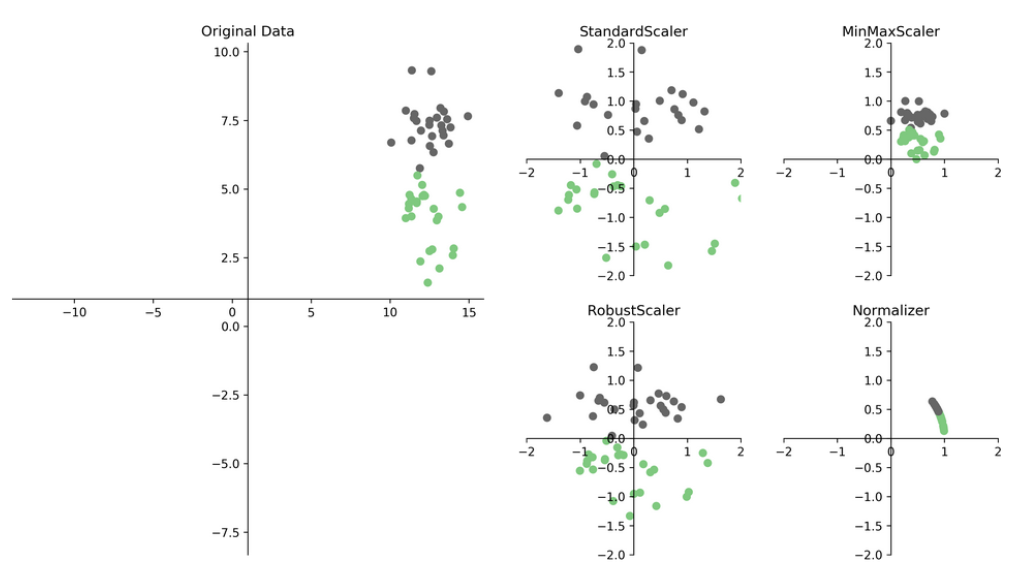

In [115]:
 # MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
housing_num_scaled = scaler.fit_transform(housing_num)
housing_num_scaled

array([[0.72908367, 0.01702128, 0.62745098, ..., 0.02927784, 0.11175091,
        0.00241382],
       [0.61653386, 0.12978723, 0.94117647, ..., 0.02541945, 0.14744727,
        0.00084158],
       [0.38545817, 0.22446809, 0.05882353, ..., 0.03373236, 0.08276226,
        0.00163435],
       ...,
       [0.59462151, 0.15744681, 0.68627451, ..., 0.02196727, 0.1898038 ,
        0.00212431],
       [0.23804781, 0.53510638, 0.2745098 , ..., 0.03904731, 0.07443667,
        0.00200105],
       [0.19223108, 0.55531915, 1.        , ..., 0.01782502, 0.23463217,
        0.00113982]])

In [116]:
housing_num_scaled.min(axis=0), housing_num_scaled.max(axis=0)

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [117]:
# MinMaxScaler with custom range
custom_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_custom_scaled = custom_scaler.fit_transform(housing_num)
housing_num_custom_scaled

array([[ 0.45816733, -0.96595745,  0.25490196, ..., -0.94144431,
        -0.77649819, -0.99517237],
       [ 0.23306773, -0.74042553,  0.88235294, ..., -0.9491611 ,
        -0.70510546, -0.99831683],
       [-0.22908367, -0.55106383, -0.88235294, ..., -0.93253528,
        -0.83447549, -0.99673131],
       ...,
       [ 0.18924303, -0.68510638,  0.37254902, ..., -0.95606547,
        -0.62039241, -0.99575137],
       [-0.52390438,  0.07021277, -0.45098039, ..., -0.92190537,
        -0.85112665, -0.99599791],
       [-0.61553785,  0.1106383 ,  1.        , ..., -0.96434996,
        -0.53073566, -0.99772036]])

In [118]:
housing_num_custom_scaled.min(axis=0), housing_num_custom_scaled.max(axis=0)

(array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

In [119]:
# StandardScaler
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)
housing_num_std_scaled

array([[ 1.27258656, -1.3728112 ,  0.34849025, ..., -0.17491646,
        -0.2117846 ,  0.05137609],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.40283542,
         0.34218528, -0.11736222],
       [-0.44760309, -0.46014647, -1.95271028, ...,  0.08821601,
        -0.66165785, -0.03227969],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ..., -0.60675918,
         0.99951387,  0.02030568],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.40217517,
        -0.79086209,  0.00707608],
       [-1.41489815,  0.99543676,  1.85617335, ..., -0.85144571,
         1.69520292, -0.08535429]])

In [120]:
housing_num_std_scaled.mean(axis=0), housing_num_std_scaled.std(axis=0)

(array([ 0.,  0., -0.,  0., -0., -0., -0., -0., -0., -0.,  0.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

# Transformation Pipelines

        There are many data transformation steps that need to be executed in the right order. Fortunately, Scikit-Learn provides the `Pipeline` class to help with such sequences of transformations.

In [121]:
# num_pipeline

from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([   ('imputer', SimpleImputer(strategy="median")),
                            ('std_scaler', StandardScaler()),
                        ])

housing_num_tr = num_pipeline.fit_transform(housing_num)

* The Pipeline constructor takes a list of name/estimator pairs defining a sequence osteps.
* All but the last estimator must be transformers (i.e., they must have afit_transform() method).
* The names can be anything you like (as long as they are unique and don’t contain double underscores, __); they will come in handy later for hyperparameter tuning.

        When you call the pipeline’s fit() method, it calls fit_transform() sequentially on all transformers, passing the output of each call as the parameter to the next call until it reaches the final estimator, for which it calls the fit() method.


In [122]:
# using make_pipeline
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(   SimpleImputer(strategy="median"),
                                StandardScaler()
                            )

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [123]:
# Combine the numerical and categorical pipelines

from sklearn.compose import ColumnTransformer
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([ ("num", num_pipeline, num_attribs),
                                    ("cat", OneHotEncoder(sparse= False, drop = 'first'), cat_attribs),
                                  ])

In [124]:
# Using make_column_transformer
from sklearn.compose import make_column_transformer
full_pipeline = make_column_transformer(    (num_pipeline, num_attribs),
                                            (OneHotEncoder(sparse= False), cat_attribs)
                                       )

In [125]:
# Transform the training data
train_features_prepared = full_pipeline.fit_transform(train_features)

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



In [126]:
train_features_prepared.shape

(16512, 16)

In [127]:
full_pipeline = make_column_transformer(    (num_pipeline, num_attribs),
                                            (OneHotEncoder(sparse= False, drop='first'), cat_attribs)
                                       )

# Transform the training data
train_features_prepared = full_pipeline.fit_transform(train_features)
train_features_prepared.shape

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



(16512, 15)

In [128]:
# Final Pipeline

num_pipeline = Pipeline([   ('imputer', SimpleImputer(strategy="median")),
                            ('std_scaler', StandardScaler()),
                        ])

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([ ("num", num_pipeline, num_attribs),
                                    ("cat", OneHotEncoder(sparse= False, drop = 'first'), cat_attribs),
                                  ])

train_features_prepared = full_pipeline.fit_transform(train_features)
# test_features_prepared = full_pipeline.transform(test_features)

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.



In [129]:
# access one hot encoder categories
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

# Select and Train a Model

# Linear Regression

        median_house_value =  w0 + w1 * median_income 
                                 + w2 * housing_median_age
                                 + w3 * total_rooms 
                                 + w4 * total_bedrooms 
                                 + w5 * population 
                                 + w6 * households 
                                 + w7 * median_income 
                                 + w8 * ocean_proximity


In [130]:
train_features_prepared

array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.70916212, -0.87669601,  1.61811813, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44760309, -0.46014647, -1.95271028, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.        ,
         0.        ,  0.        ],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41489815,  0.99543676,  1.85617335, ...,  0.        ,
         1.        ,  0.        ]])

In [131]:
median_income = train_features_prepared[:,7] 
median_income

array([-0.326196  , -0.03584338,  0.14470145, ..., -0.49697313,
        0.96545045, -0.68544764])

In [132]:
median_house_value = train_labels.values
median_house_value

array([103000., 382100., 172600., ..., 222100., 283500., 325000.])

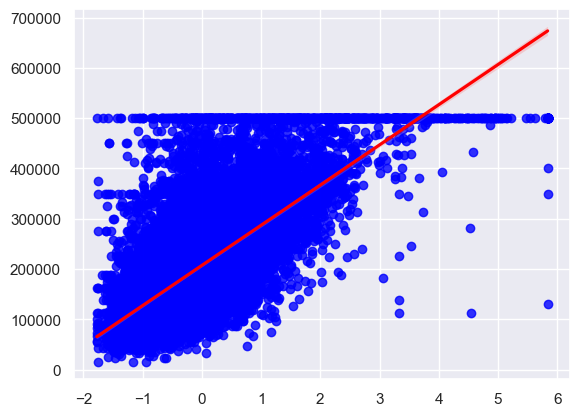

In [133]:
# draw a scatter plot with regression line
sns.regplot(x=median_income, y=median_house_value, scatter_kws={"color": "blue"}, line_kws={"color": "red"});

In [134]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(train_features_prepared, train_labels)

# Predictions
lin_reg_predictions = lin_reg.predict(train_features_prepared)

# Decision Tree 

        Decision Tree is a flowchart-like structure in which each internal node represents a "test" on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label (decision taken after computing all attributes). The paths from root to leaf represent classification rules. 

      

In [135]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor()
tree.fit(train_features_prepared, train_labels)

# Predictions
tree_predictions = tree.predict(train_features_prepared)

In [136]:
# Training Accuracy
from sklearn.metrics import r2_score
print("Linear Regression Accuracy: ", r2_score(train_labels, lin_reg_predictions))
print("Decision Tree Accuracy: ", r2_score(train_labels, tree_predictions))

Linear Regression Accuracy:  0.6582199160539229
Decision Tree Accuracy:  1.0


* Linear Regression model is underfitting the data.
* Decision Tree model is overfitting the data.

# Cross Validation

In [137]:
# Cross Validation for Linear Regression

from sklearn.model_selection import cross_val_score
lin_reg_scores = cross_val_score(lin_reg, train_features_prepared, train_labels, scoring="r2", cv=10)

print("Linear Regression Accuracy: ", lin_reg_scores)
print("Linear Regression Accuracy: ", round(lin_reg_scores.mean(),2))
print("Linear Regression Standard Deviation: ", round(lin_reg_scores.std(),2))


Linear Regression Accuracy:  [0.6844558  0.63984019 0.66257534 0.65302029 0.6495965  0.68626001
 0.6720221  0.64219732 0.61037649 0.65311922]
Linear Regression Accuracy:  0.66
Linear Regression Standard Deviation:  0.02


In [138]:
# Cross Validation for Decision Tree
from sklearn.model_selection import cross_val_score
tree_scores = cross_val_score(tree, train_features_prepared, train_labels, scoring="r2", cv=10)

print("Scores:", tree_scores)
print("Mean:", round(tree_scores.mean(),2))
print("Standard deviation:", round(tree_scores.std(),2))

Scores: [0.67675074 0.63732965 0.63724614 0.59565212 0.59432812 0.65164445
 0.65033506 0.646284   0.67152977 0.64072002]
Mean: 0.64
Standard deviation: 0.03


# Fine-Tune Your Model

In [139]:
# Find the best model using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [2, 3, 4, 5] , 'max_features': [2, 4, 6, 8]}
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(train_features_prepared, train_labels)
grid_search.best_params_

{'max_depth': 5, 'max_features': 8}

In [140]:
# Cross Validation for Decision Tree
tree5 = DecisionTreeRegressor(max_depth=5, max_features=8)
tree5.fit(train_features_prepared, train_labels)

# Predictions
tree5_predictions = tree5.predict(train_features_prepared)

In [141]:
feature_names = full_pipeline._columns[0]+ cat_encoder.categories_[0].tolist()
feature_names.remove('<1H OCEAN')
feature_names

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household',
 'INLAND',
 'ISLAND',
 'NEAR BAY',
 'NEAR OCEAN']

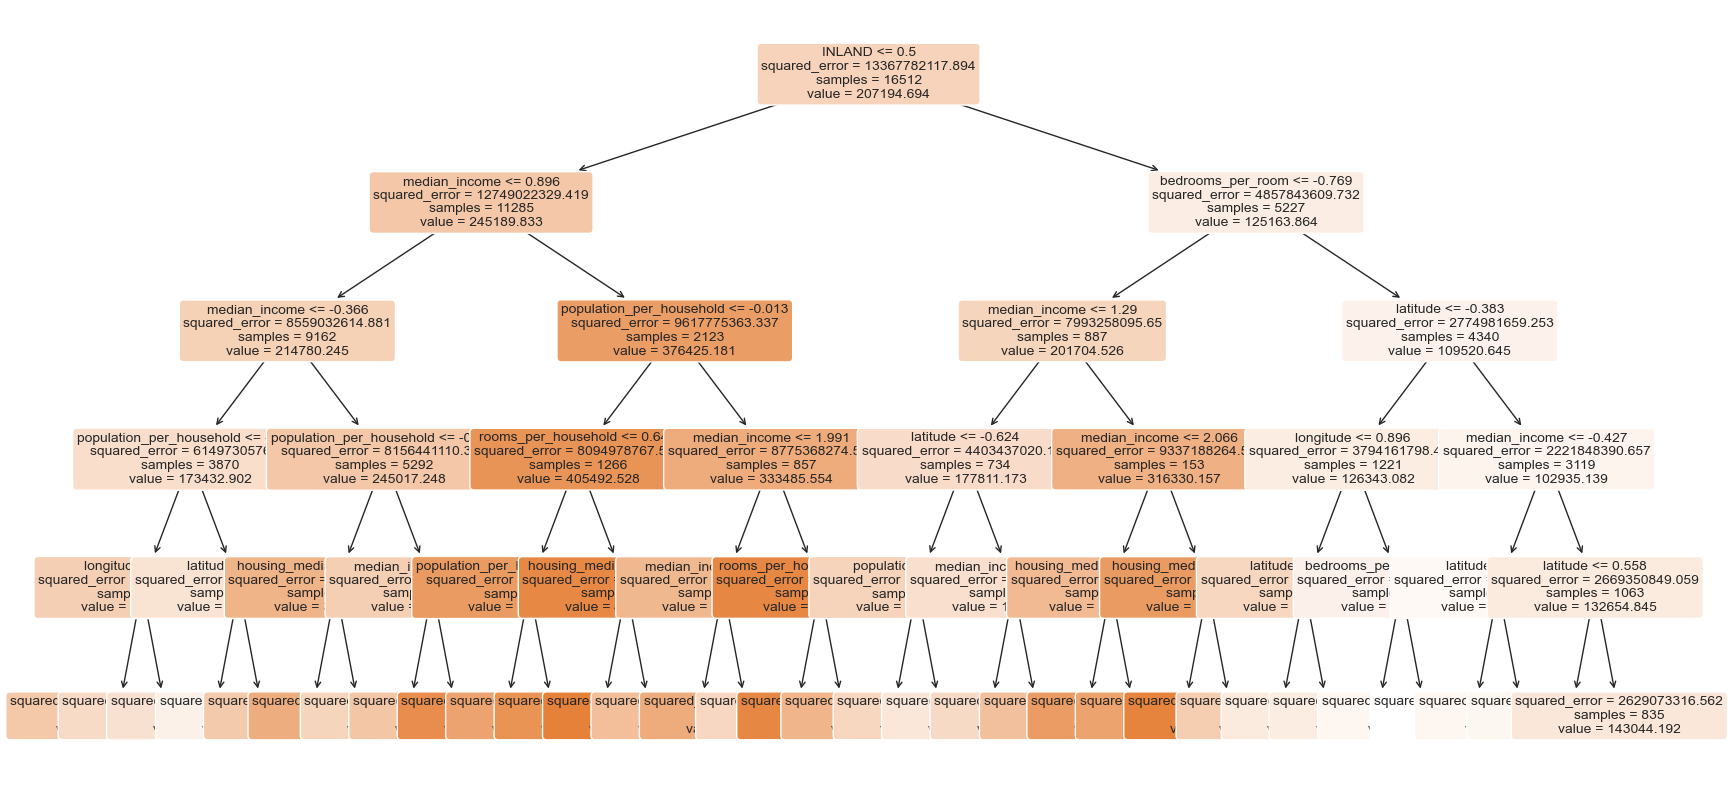

In [142]:
# plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree5, feature_names=feature_names, filled=True, rounded=True, fontsize=10);

In [143]:
# Testing Accuracy
test_features = test_set.drop("median_house_value", axis=1)
test_features['rooms_per_household'] = test_features['total_rooms']/test_features['households']
test_features['bedrooms_per_room'] = test_features['total_bedrooms']/test_features['total_rooms']
test_features['population_per_household'] = test_features['population']/test_features['households']
test_labels = test_set["median_house_value"].copy()

test_features_prepared = full_pipeline.transform(test_features)

lin_reg_predictions_test = lin_reg.predict(test_features_prepared)
tree5_predictions_test = tree5.predict(test_features_prepared)

print("Linear Regression Accuracy on Test Data: ", r2_score(test_labels, lin_reg_predictions_test))
print("Decision Tree Accuracy on Test Data: ", r2_score(test_labels, tree5_predictions_test))

Linear Regression Accuracy on Test Data:  0.6353392335238193
Decision Tree Accuracy on Test Data:  0.6455614251205382


In [144]:
# Linear Regression vs. Decision Tree Training and Testing Accuracy
pd.DataFrame({ "Linear Regression": [r2_score(train_labels, lin_reg_predictions), r2_score(test_labels, lin_reg_predictions_test)],
                "Decision Tree": [r2_score(train_labels, tree5_predictions), r2_score(test_labels, tree5_predictions_test)]},
                index=["Training Accuracy", "Testing Accuracy"])

,Linear Regression,Decision Tree
Training Accuracy,0.658220,0.672867
Testing Accuracy,0.635339,0.645561


# Save Your Model

In [145]:
# save linear regression model
import joblib
joblib.dump(lin_reg, "lin_reg.pkl")

['lin_reg.pkl']

In [146]:
# Load the model
lin_reg = joblib.load("lin_reg.pkl")

# Use the model to make predictions
lin_reg_predictions_test = lin_reg.predict(test_features_prepared)


In [147]:
# Save Pipeline
import joblib
joblib.dump(full_pipeline, "full_pipeline.pkl")

['full_pipeline.pkl']

#  Web App

In [148]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np
import pandas as pd

# Load the model
lin_reg = joblib.load("lin_reg.pkl")

# Load the pipeline
full_pipeline = joblib.load("full_pipeline.pkl")

# Load the data
housing = pd.read_csv("https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv")

# Create a title and sub-title
st.title("California Housing Price Prediction App")

st.write("""
This app predicts the **California Housing Price**!
""")

# Take the input from the user
longitude = st.slider('longitude', float(housing['longitude'].min()), float(housing['longitude'].max()))
latitude = st.slider('latitude', float(housing['latitude'].min()), float(housing['latitude'].max()))

housing_median_age = st.slider('housing_median_age', float(housing['housing_median_age'].min()), float(housing['housing_median_age'].max()))
total_rooms = st.slider('total_rooms', float(housing['total_rooms'].min()), float(housing['total_rooms'].max()))
total_bedrooms = st.slider('total_bedrooms', float(housing['total_bedrooms'].min()), float(housing['total_bedrooms'].max()))
population = st.slider('population', float(housing['population'].min()), float(housing['population'].max()))
households = st.slider('households', float(housing['households'].min()), float(housing['households'].max()))
median_income = st.slider('median_income', float(housing['median_income'].min()), float(housing['median_income'].max()))

ocean_proximity = st.selectbox('ocean_proximity', ('<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'))

# Store a dictionary into a variable
user_data = {'longitude': longitude,

'latitude': latitude,   
'housing_median_age': housing_median_age,
'total_rooms': total_rooms,
'total_bedrooms': total_bedrooms,
'population': population,
'households': households,
'median_income': median_income,
'ocean_proximity': ocean_proximity}

# Transform the data into a data frame
features = pd.DataFrame(user_data, index=[0])

# Additional transformations
features['rooms_per_household'] = features['total_rooms']/features['households']
features['bedrooms_per_room'] = features['total_bedrooms']/features['total_rooms']
features['population_per_household'] = features['population']/features['households']

# Pipeline
features_prepared = full_pipeline.transform(features)

# Predict the output
prediction = lin_reg.predict(features_prepared)[0]

# Set a subheader and display the prediction
st.subheader('Prediction')
st.markdown('''# $ {} '''.format(round(prediction), 2))


Overwriting app.py


In [149]:
!streamlit run app.py

^C
